# 🤖 04 - Advanced Model Building

In this notebook, we'll train several machine learning models to predict customer churn using our engineered dataset.
We'll focus on **Algorithm Arsenal** (Logistic Regression, Random Forest, XGBoost), **Rigorous Evaluation** (Precision, Recall, F1-Score, ROC-AUC), and **Hyperparameter Optimization**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost
    from xgboost import XGBClassifier

sns.set_theme(style="whitegrid", palette="muted")
import warnings
warnings.filterwarnings('ignore')

## 1. Load Engineered Data

In [2]:
df = pd.read_csv('../data/telco_churn_engineered.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7043, 32)


,tenure,monthly_charges,total_charges,churn,num_additional_services,avg_charge_per_month,is_high_value,gender_Male,senior_citizen_Yes,partner_Yes,...,contract_Two year,paperless_billing_Yes,payment_method_Credit card (automatic),payment_method_Electronic check,payment_method_Mailed check,tenure_group_1-2 Years,tenure_group_2-3 Years,tenure_group_3-4 Years,tenure_group_4-5 Years,tenure_group_5+ Years
0,-0.608696,-0.745170,-0.402798,0,-0.333333,-0.782675,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
1,0.108696,-0.246550,0.146087,0,0.000000,-0.118256,0,1,0,0,...,0,0,0,0,1,0,1,0,0,0
2,-0.586957,-0.303588,-0.379687,1,0.000000,-0.423341,0,1,0,0,...,0,1,0,0,1,0,0,0,0,0
3,0.347826,-0.516099,0.131698,0,0.333333,-0.355874,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
4,-0.586957,0.006440,-0.366848,1,-0.666667,-0.176697,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


## 2. Train-Test Split

In [3]:
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 5634
Test set size: 1409


## 3. Algorithm Arsenal
Let's define a helper function to evaluate our models.

In [4]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}\n")
    
    return {'Model': model_name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'ROC-AUC': roc_auc}

### Logistic Regression (Interpretable Baseline)

In [5]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
res_lr = evaluate_model(lr, X_test, y_test, "Logistic Regression")

--- Logistic Regression ---
Accuracy:  0.8098
Precision: 0.6791
Recall:    0.5374
F1-Score:  0.6000
ROC-AUC:   0.8453



### Random Forest (Ensemble Method)

In [6]:
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
res_rf = evaluate_model(rf, X_test, y_test, "Random Forest")

--- Random Forest ---
Accuracy:  0.7991
Precision: 0.6679
Recall:    0.4840
F1-Score:  0.5612
ROC-AUC:   0.8454



### XGBoost (Advanced Gradient Boosting)

In [7]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, learning_rate=0.05, max_depth=5)
xgb.fit(X_train, y_train)
res_xgb = evaluate_model(xgb, X_test, y_test, "XGBoost")

--- XGBoost ---
Accuracy:  0.7963
Precision: 0.6445
Recall:    0.5187
F1-Score:  0.5748
ROC-AUC:   0.8435



## 4. Rigorous Evaluation & Comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.809794,0.679054,0.537433,0.600000,0.845300
Random Forest,0.799148,0.667897,0.483957,0.561240,0.845374
XGBoost,0.796309,0.644518,0.518717,0.574815,0.843505


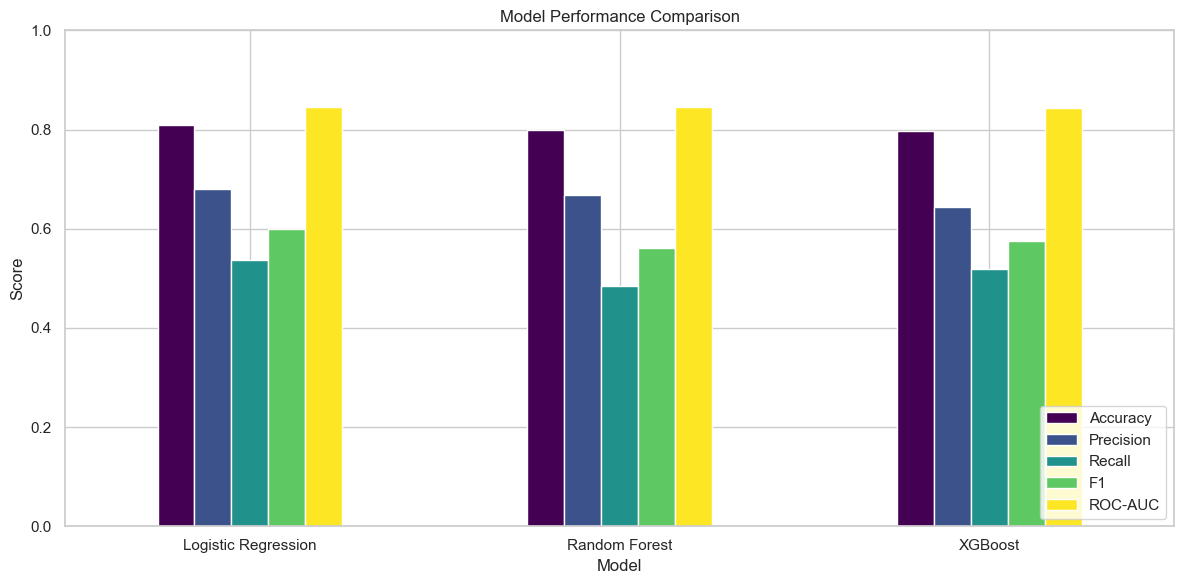

In [8]:
results = pd.DataFrame([res_lr, res_rf, res_xgb]).set_index('Model')
display(results)

results.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()